# Lab 3: From raw text to a flattened latent vector

Aim

- Turn five customer reviews into numbers: clean the text, build a vocabulary, map words to token IDs, pad, embed, flatten, and plot the embeddings with PCA.
- Each of the 8 tasks in the brief has its own labelled section, and each code cell ends with an `assert` that checks the task was really done.

Dataset

| # | Review |
|---|---|
| S1 | The product quality is excellent |
| S2 | I really love this product |
| S3 | The quality of this item is amazing |
| S4 | The product performance is poor |
| S5 | I dislike this product completely |

Complexity / self-learning element (Part B)

- Every stage is written twice: once by hand in NumPy/Python and once with the Keras built-in, and the two must give identical output.
- The embeddings are trained, not left random, and the claims about them are re-checked over 5 seeds.
- Flatten is compared with average pooling, which turns out to squash every word onto a single line.
- A skip-gram word2vec is written from scratch and learns embeddings with no labels at all, and it places "love" next to "dislike".
- New reviews, including one with a word the model has never seen, go through the full pipeline.

## Step 0: Setup

- One seed fixes the random embedding weights, so every number quoted below comes back the same on a rerun.
- The brief gives no labels, so I read each review and marked S1-S3 positive (1) and S4-S5 negative (0), because training the embedding layer needs a target.
- Only the embedding training in Task 5 uses these labels, and Tasks 1-4 never see them.

In [1]:
import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.decomposition import PCA

SEED = 42
tf.keras.utils.set_random_seed(SEED)
os.makedirs("outputs", exist_ok=True)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

texts = [
    "The product quality is excellent",
    "I really love this product",
    "The quality of this item is amazing",
    "The product performance is poor",
    "I dislike this product completely",
]
labels = np.array([1, 1, 1, 0, 0], dtype="float32")   # 1 = positive, 0 = negative (my reading)
names = [f"S{i + 1}" for i in range(len(texts))]

# One colour per sentiment group, reused in every plot.
C_POS, C_NEG, C_MIX, C_SPECIAL = "#2a9d8f", "#e76f51", "#8d99ae", "#bbbbbb"
checks = {}   # task -> result of its verification, printed as a checklist at the end

print("tensorflow  :", tf.__version__)
print("numpy       :", np.__version__)
print(pd.DataFrame({"review": texts, "label": labels.astype(int)}, index=names))

assert len(texts) == len(labels) == 5
print("\nStep 0 verified: 5 reviews and 5 labels loaded, seed fixed at", SEED)

tensorflow  : 2.21.0
numpy       : 2.5.3
                                 review  label
S1     The product quality is excellent      1
S2           I really love this product      1
S3  The quality of this item is amazing      1
S4      The product performance is poor      0
S5    I dislike this product completely      0

Step 0 verified: 5 reviews and 5 labels loaded, seed fixed at 42


## Task 1: Pre-process the text and build the vocabulary

- Pre-processing is lower-casing, removing anything that is not a letter or a space, and splitting on whitespace.
- Lower-casing matters here because "The" and "the" would otherwise be two different words.
- Stop words such as "the" and "is" are kept, because the brief asks for all unique words and dropping them would change nothing we can test on five sentences.
- The vocabulary is ordered by frequency, and ties keep the order the word first appears in, which is the rule the classic Keras `Tokenizer` used.

In [2]:
def clean(text):
    """Lower-case, keep letters and spaces only, collapse repeated spaces."""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def tokenize(text):
    return clean(text).split()


tokens = [tokenize(t) for t in texts]
pd.DataFrame({"raw": texts, "cleaned": [clean(t) for t in texts],
              "tokens": tokens, "n_tokens": [len(t) for t in tokens]}, index=names)

,raw,cleaned,tokens,n_tokens
S1,The product quality is excellent,the product quality is excellent,"[the, product, quality, is, excellent]",5
S2,I really love this product,i really love this product,"[i, really, love, this, product]",5
S3,The quality of this item is amazing,the quality of this item is amazing,"[the, quality, of, this, item, is, amazing]",7
S4,The product performance is poor,the product performance is poor,"[the, product, performance, is, poor]",5
S5,I dislike this product completely,i dislike this product completely,"[i, dislike, this, product, completely]",5


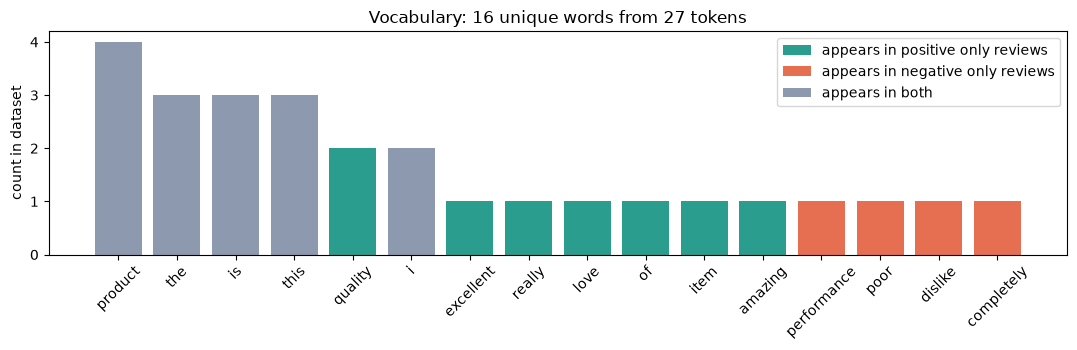

unique words: 16
['product', 'the', 'is', 'this', 'quality', 'i', 'excellent', 'really', 'love', 'of', 'item', 'amazing', 'performance', 'poor', 'dislike', 'completely']

Task 1 verified: 16 unique words, identical to the set Keras builds on its own


In [3]:
counts = Counter(w for sent in tokens for w in sent)
first_seen = {}
for sent in tokens:
    for w in sent:
        first_seen.setdefault(w, len(first_seen))

vocab_words = sorted(counts, key=lambda w: (-counts[w], first_seen[w]))

# Which sentiment each word appears in, used only for colouring the plots.
def word_group(w):
    in_pos = any(w in tokens[i] for i in range(5) if labels[i] == 1)
    in_neg = any(w in tokens[i] for i in range(5) if labels[i] == 0)
    return "positive only" if in_pos and not in_neg else "negative only" if in_neg and not in_pos else "both"

group_colour = {"positive only": C_POS, "negative only": C_NEG, "both": C_MIX}
groups = {w: word_group(w) for w in vocab_words}

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(vocab_words, [counts[w] for w in vocab_words], color=[group_colour[groups[w]] for w in vocab_words])
ax.set_ylabel("count in dataset")
ax.set_title(f"Vocabulary: {len(vocab_words)} unique words from {sum(counts.values())} tokens")
ax.tick_params(axis="x", rotation=45)
for g, c in group_colour.items():
    ax.bar(0, 0, color=c, label=f"appears in {g} reviews" if g != "both" else "appears in both")
ax.legend()
plt.tight_layout()
plt.show()

print("unique words:", len(vocab_words))
print(vocab_words)

# Verify 1: the word count is right (5 + 5 + 7 + 5 + 5 = 27 tokens).
assert sum(counts.values()) == 27 and len(vocab_words) == len(set(vocab_words)) == 16
# Verify 2: Keras TextVectorization, adapted on the raw text, finds the same words with the same counts.
tv_auto = tf.keras.layers.TextVectorization()
tv_auto.adapt(texts)
keras_words = [str(w) for w in tv_auto.get_vocabulary()[2:]]
assert set(keras_words) == set(vocab_words)
checks["Task 1  vocabulary of unique words"] = "16 words, same set as Keras TextVectorization"
print("\nTask 1 verified: 16 unique words, identical to the set Keras builds on its own")

Observation

- The 5 reviews hold 27 tokens and 16 unique words, and cleaning changed only the capital T and I.
- "product" is the most frequent word (4 times), followed by "the", "is" and "this" (3 each).
- 7 words appear only in positive reviews, 4 only in negative ones, and 5 in both, so most words carry a sentiment signal on this tiny dataset.

## Task 2: Give every word a unique token ID

- ID 0 is reserved for `<PAD>`, the filler used in Task 4, so padding can never be confused with a real word.
- ID 1 is reserved for `<OOV>` (out of vocabulary), so a word the model never saw still gets an ID instead of crashing the pipeline.
- Real words start at ID 2, which gives a vocabulary size of 18.

In [4]:
PAD, OOV = "<PAD>", "<OOV>"
id_to_word = [PAD, OOV] + vocab_words
word_to_id = {w: i for i, w in enumerate(id_to_word)}
VOCAB_SIZE = len(id_to_word)

vocab_table = pd.DataFrame({
    "token_id": range(VOCAB_SIZE),
    "word": id_to_word,
    "count": [0, 0] + [counts[w] for w in vocab_words],
    "appears in": ["special", "special"] + [groups[w] for w in vocab_words],
}).set_index("token_id")
print("vocabulary size:", VOCAB_SIZE)
vocab_table.T

vocabulary size: 18


token_id,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
word,<PAD>,<OOV>,product,the,is,this,quality,i,excellent,really,love,of,item,amazing,performance,poor,dislike,completely
count,0,0,4,3,3,3,2,2,1,1,1,1,1,1,1,1,1,1
appears in,special,special,both,both,both,both,positive only,both,positive only,positive only,positive only,positive only,positive only,positive only,negative only,negative only,negative only,negative only


In [5]:
# Verify: IDs run 0..17 with no gaps, and word -> id -> word gives back the same word.
assert sorted(word_to_id.values()) == list(range(VOCAB_SIZE))
assert all(id_to_word[word_to_id[w]] == w for w in id_to_word)
assert word_to_id[PAD] == 0 and word_to_id[OOV] == 1
checks["Task 2  unique token ID per word"] = "IDs 0..17, one-to-one, 0 = PAD, 1 = OOV"
print("Task 2 verified: 18 unique IDs, one-to-one with words")

Task 2 verified: 18 unique IDs, one-to-one with words


Observation

- The vocabulary has 18 IDs: 0 for `<PAD>`, 1 for `<OOV>`, and 2-17 for the 16 words in frequency order.
- "product" gets ID 2 because it is the most frequent word, and the 10 words seen once fill IDs 8-17.

## Task 3: Turn each sentence into a sequence of token IDs

- `encode` looks every token up in the vocabulary and uses ID 1 for anything it does not find.
- `decode` goes the other way, which proves no information was lost.
- Sequences still have different lengths here (5, 5, 7, 5, 5), which is the problem Task 4 fixes.

In [6]:
def encode(text):
    return [word_to_id.get(w, word_to_id[OOV]) for w in tokenize(text)]


def decode(ids):
    return " ".join(id_to_word[i] for i in ids if i != 0)


sequences = [encode(t) for t in texts]
for n, t, s in zip(names, texts, sequences):
    pairs = "  ".join(f"{w}:{i}" for w, i in zip(tokenize(t), s))
    print(f"{n}  {str(s):<32} {pairs}")

# Verify 1: decoding gives back the cleaned sentence exactly.
assert all(decode(s) == clean(t) for s, t in zip(sequences, texts))
# Verify 2: Keras TextVectorization, given my vocabulary, produces the same IDs.
tv = tf.keras.layers.TextVectorization(vocabulary=vocab_words, standardize="lower_and_strip_punctuation")
keras_seq = tv(texts).numpy()
assert all(keras_seq[i, :len(s)].tolist() == s for i, s in enumerate(sequences))
assert list(tv.get_vocabulary()) == ["", "[UNK]"] + vocab_words   # Keras also puts PAD at 0 and OOV at 1

unseen = "The product is terrible"
print(f"\nunseen review : '{unseen}' -> {encode(unseen)}   ('terrible' is not in the vocabulary, so it becomes 1 = <OOV>)")
checks["Task 3  sentences as token-ID sequences"] = "decode(encode(x)) == x, same IDs as Keras"
print("\nTask 3 verified: round trip is lossless and matches Keras TextVectorization")

S1  [3, 2, 6, 4, 8]                  the:3  product:2  quality:6  is:4  excellent:8
S2  [7, 9, 10, 5, 2]                 i:7  really:9  love:10  this:5  product:2
S3  [3, 6, 11, 5, 12, 4, 13]         the:3  quality:6  of:11  this:5  item:12  is:4  amazing:13
S4  [3, 2, 14, 4, 15]                the:3  product:2  performance:14  is:4  poor:15
S5  [7, 16, 5, 2, 17]                i:7  dislike:16  this:5  product:2  completely:17

unseen review : 'The product is terrible' -> [3, 2, 4, 1]   ('terrible' is not in the vocabulary, so it becomes 1 = <OOV>)

Task 3 verified: round trip is lossless and matches Keras TextVectorization


Observation

- S1 "The product quality is excellent" becomes `[3, 2, 6, 4, 8]`, and "product" is ID 2 in every review it appears in.
- Keras `TextVectorization` with the same vocabulary gives the same IDs, and it also keeps 0 for padding and 1 for unknown words.
- The unseen review "The product is terrible" encodes to `[3, 2, 4, 1]`, so the unknown word "terrible" is kept as `<OOV>` instead of being dropped.

## Task 4: Pad every sequence to the same length

- The longest review, S3, has 7 tokens, so `MAX_LEN = 7` pads without cutting any word off.
- Post-padding adds zeros at the end, so the first word of every review sits in column 0.
- Aligned starts matter for Task 7, because after flattening each column block belongs to one word position.
- The result is a 5 x 7 integer matrix, one row per review, which a model can take as a single batch.

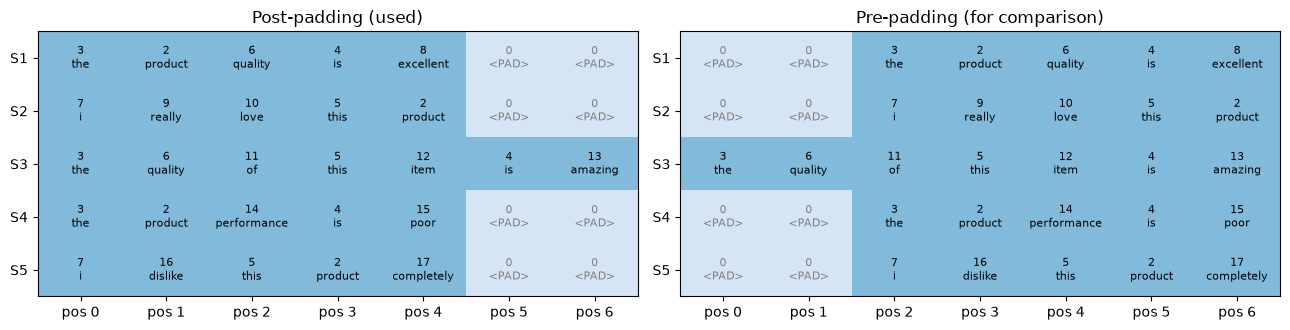

padded matrix X, shape (5, 7)
[[ 3  2  6  4  8  0  0]
 [ 7  9 10  5  2  0  0]
 [ 3  6 11  5 12  4 13]
 [ 3  2 14  4 15  0  0]
 [ 7 16  5  2 17  0  0]]
padding share: 22.9% of the 35 cells

Task 4 verified: uniform 5 x 7 matrix, identical to Keras pad_sequences


In [7]:
MAX_LEN = max(len(s) for s in sequences)


def pad(seqs, maxlen, value=0):
    """Post-pad with `value` and post-truncate to `maxlen`."""
    return np.array([(s + [value] * maxlen)[:maxlen] for s in seqs], dtype="int32")


X = pad(sequences, MAX_LEN)
X_pre = tf.keras.utils.pad_sequences(sequences, maxlen=MAX_LEN, padding="pre")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
for ax, M, title in [(axes[0], X, "Post-padding (used)"), (axes[1], X_pre, "Pre-padding (for comparison)")]:
    ax.imshow(M > 0, cmap="Blues", vmin=-0.6, vmax=3, aspect="auto")
    for r in range(M.shape[0]):
        for c in range(M.shape[1]):
            ax.text(c, r, f"{M[r, c]}\n{id_to_word[M[r, c]]}", ha="center", va="center", fontsize=8,
                    color="black" if M[r, c] else "grey")
    ax.set_xticks(range(MAX_LEN), [f"pos {i}" for i in range(MAX_LEN)])
    ax.set_yticks(range(5), names)
    ax.set_title(title)
plt.tight_layout()
plt.show()

print("padded matrix X, shape", X.shape)
print(X)
print("padding share:", f"{(X == 0).mean():.1%}", "of the 35 cells")

# Verify 1: every row has length 7 and my pad() matches the Keras built-in.
assert X.shape == (5, MAX_LEN) == (5, 7)
assert np.array_equal(X, tf.keras.utils.pad_sequences(sequences, maxlen=MAX_LEN, padding="post"))
# Verify 2: removing the zeros gives back the original sequences.
assert all(row[row > 0].tolist() == s for row, s in zip(X, sequences))
checks["Task 4  padded sequences"] = "5 x 7 matrix, equals keras pad_sequences(post)"
print("\nTask 4 verified: uniform 5 x 7 matrix, identical to Keras pad_sequences")

Observation

- All five reviews are now 7 IDs long, and 8 of the 35 cells (22.9%) are padding.
- S3 needs no padding, and each of the other four reviews gets two zeros at the end.
- With pre-padding S3 would still start at column 0 while the rest start at column 2, so the same word position would land in different columns.

## Task 5: Word embeddings, from one token ID to a dense vector

- An embedding layer is a lookup table with one row per token ID, so an 18-word vocabulary with 8 dimensions is an 18 x 8 matrix.
- 8 dimensions is less than half the 18 a one-hot vector would need, and small enough to read every number in a heatmap.
- Looking up row *i* is the same maths as multiplying a one-hot vector for *i* by the matrix, which is what I check below.

### Step 5a: The embedding layer before training

In [8]:
EMB_DIM = 8

embedding = tf.keras.layers.Embedding(VOCAB_SIZE, EMB_DIM, name="embedding")
E_batch = embedding(X).numpy()                       # (5, 7, 8)
W_init = embedding.get_weights()[0].copy()           # (18, 8)

# Hand-written lookup: one-hot (5, 7, 18) times the matrix (18, 8).
one_hot = np.eye(VOCAB_SIZE, dtype="float32")[X]
E_manual = one_hot @ W_init

print("token IDs X       :", X.shape)
print("one-hot           :", one_hot.shape, "-> mostly zeros:", f"{(one_hot == 0).mean():.1%}")
print("embedding matrix W:", W_init.shape)
print("embedded batch    :", E_batch.shape, "(sentences, positions, dimensions)")
print("\nword 'product' (ID 2) before training:", W_init[2].round(4))

# Verify: Keras lookup == one-hot @ W, to float precision.
assert E_batch.shape == (5, MAX_LEN, EMB_DIM)
assert np.allclose(E_batch, E_manual, atol=1e-7)
print("\nStep 5a verified: Keras Embedding lookup equals one-hot x W")

token IDs X       : (5, 7)
one-hot           : (5, 7, 18) -> mostly zeros: 94.4%
embedding matrix W: (18, 8)
embedded batch    : (5, 7, 8) (sentences, positions, dimensions)

word 'product' (ID 2) before training: [-0.0481 -0.0308  0.0014 -0.0434 -0.0462  0.0348  0.0415 -0.0237]

Step 5a verified: Keras Embedding lookup equals one-hot x W


Observation

- The 5 x 7 ID matrix becomes a 5 x 7 x 8 tensor, so each ID turned into 8 numbers.
- The one-hot version of the same input is 94.4% zeros, which is why a lookup table beats multiplying one-hot vectors in practice.
- Before training "product" is `[-0.048, -0.031, 0.001, ...]`: small random numbers from Keras's uniform(-0.05, 0.05) start, with no meaning yet.

### Step 5b: Train the embeddings so the numbers mean something

- Random vectors from 5a carry no meaning, so the matrix is trained the way the reference notebook does it: embedding, then flatten, then a sigmoid unit that predicts the sentiment label.
- The loss gradient flows back into the rows of the words in each review, so words from positive reviews get pushed one way and words from negative reviews the other.
- Adam at learning rate 0.01 for 150 full-batch epochs is enough for the loss to flatten out on 5 samples.
- 100% training accuracy on 5 reviews says nothing about generalising, and the only goal here is useful vectors.

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ token_ids (InputLayer)          │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 7, 8)           │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 56)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment (Dense)               │ (None, 1)              │            57 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201 (804.00 B)

 Trainable params: 201 (804.00 B)

 Non-trainable params: 0 (0.00 B)

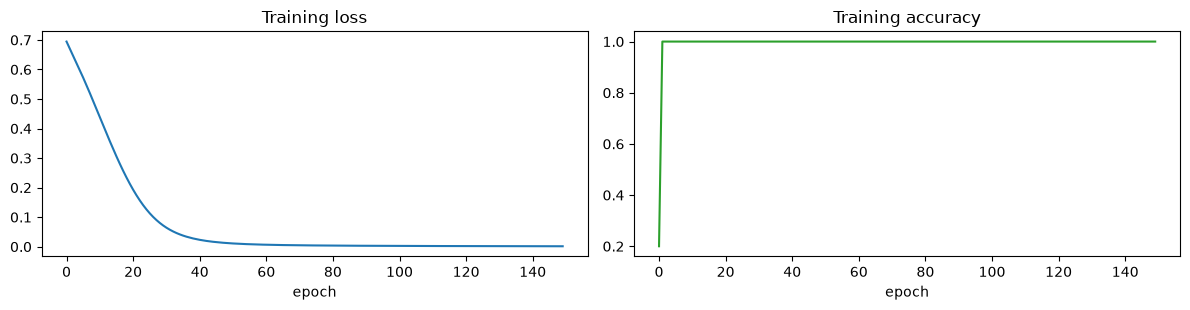

loss     : 0.6945 -> 0.0014
accuracy : 0.20 -> 1.00
predicted: [0.998 0.999 1.    0.002 0.001]  true: [1 1 1 0 0]

Step 5b verified: embedding matrix trained, shape (18, 8)


In [9]:
def build_model(seed, pooling="flatten"):
    tf.keras.utils.set_random_seed(seed)
    inp = tf.keras.Input(shape=(MAX_LEN,), dtype="int32", name="token_ids")
    emb = tf.keras.layers.Embedding(VOCAB_SIZE, EMB_DIM, mask_zero=(pooling == "average"), name="embedding")(inp)
    if pooling == "flatten":
        h = tf.keras.layers.Flatten(name="flatten")(emb)
    else:
        h = tf.keras.layers.GlobalAveragePooling1D(name="average")(emb)
    out = tf.keras.layers.Dense(1, activation="sigmoid", name="sentiment")(h)
    model = tf.keras.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss="binary_crossentropy", metrics=["accuracy"])
    return model


EPOCHS = 150
model = build_model(SEED)
model.summary()
W_before = model.get_layer("embedding").get_weights()[0].copy()
history = model.fit(X, labels, epochs=EPOCHS, batch_size=5, verbose=0)
W = model.get_layer("embedding").get_weights()[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
axes[0].plot(history.history["loss"]); axes[0].set_title("Training loss"); axes[0].set_xlabel("epoch")
axes[1].plot(history.history["accuracy"], color="tab:green"); axes[1].set_title("Training accuracy"); axes[1].set_xlabel("epoch")
plt.tight_layout()
plt.show()

print(f"loss     : {history.history['loss'][0]:.4f} -> {history.history['loss'][-1]:.4f}")
print(f"accuracy : {history.history['accuracy'][0]:.2f} -> {history.history['accuracy'][-1]:.2f}")
print("predicted:", model.predict(X, verbose=0).ravel().round(3), " true:", labels.astype(int))

# Verify: loss fell by more than 90%, all 5 reviews are classified correctly, and the matrix is still 18 x 8.
assert history.history["loss"][-1] < 0.1 * history.history["loss"][0]
assert history.history["accuracy"][-1] == 1.0 and W.shape == (VOCAB_SIZE, EMB_DIM)
print("\nStep 5b verified: embedding matrix trained, shape", W.shape)

Observation

- The model has 201 parameters: 144 in the 18 x 8 embedding table and 57 in the output unit (56 weights and a bias).
- Loss fell from 0.6945 (a coin flip is 0.693) to 0.0014, and accuracy went from 0.20 to 1.00.
- The predictions are 0.998, 0.999, 1.000 for the positive reviews and 0.002, 0.001 for the negative ones.

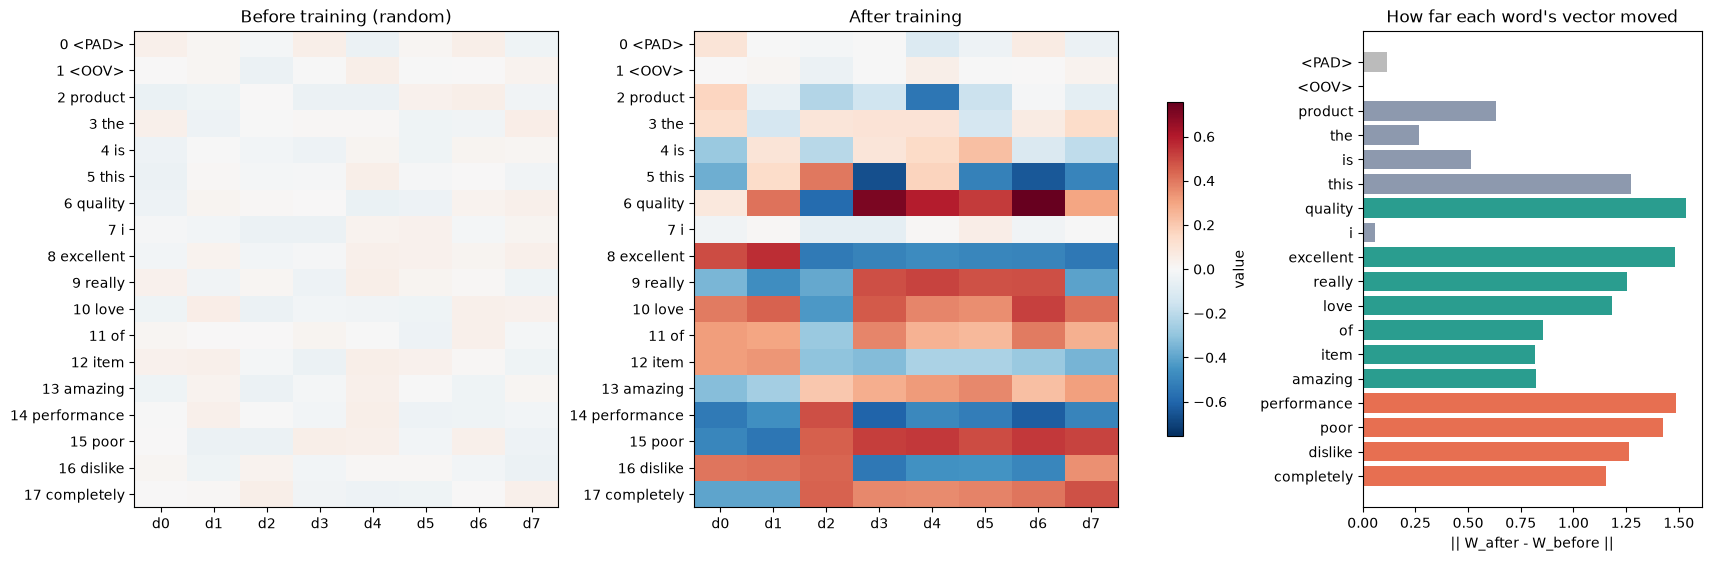

quality        1.532
performance    1.489
excellent      1.483
poor           1.425
this           1.273
dislike        1.264
really         1.255
love           1.183
completely     1.152
of             0.858
amazing        0.825
item           0.819
product        0.631
is             0.513
the            0.269
<PAD>          0.114
i              0.060
<OOV>          0.000

Task 5 verified: every token ID now maps to a trained 8-D vector


In [10]:
moved = np.linalg.norm(W - W_before, axis=1)
lim = np.abs(W).max()

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), gridspec_kw={"width_ratios": [1, 1, 0.8]}, layout="constrained")
for ax, M, title in [(axes[0], W_before, "Before training (random)"), (axes[1], W, "After training")]:
    im = ax.imshow(M, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
    ax.set_yticks(range(VOCAB_SIZE), [f"{i} {w}" for i, w in enumerate(id_to_word)])
    ax.set_xticks(range(EMB_DIM), [f"d{j}" for j in range(EMB_DIM)])
    ax.set_title(title)
fig.colorbar(im, ax=axes[:2], shrink=0.7, label="value")
colours = [C_SPECIAL, C_SPECIAL] + [group_colour[groups[w]] for w in vocab_words]
axes[2].barh(range(VOCAB_SIZE), moved, color=colours)
axes[2].set_yticks(range(VOCAB_SIZE), id_to_word)
axes[2].invert_yaxis()
axes[2].set_title("How far each word's vector moved")
axes[2].set_xlabel("|| W_after - W_before ||")
plt.show()

print(pd.Series(moved, index=id_to_word).round(3).sort_values(ascending=False).to_string())
# Verify: <OOV> never appears in the data, so its row must not move at all.
assert moved[1] < 1e-6
checks["Task 5  word embeddings (dense 8-D vectors)"] = "18 x 8 matrix trained, lookup == one-hot @ W"
print("\nTask 5 verified: every token ID now maps to a trained 8-D vector")

Observation

- Words that appear in only one sentiment moved the most: quality 1.53, performance 1.49, excellent 1.48, poor 1.43.
- "i" barely moved (0.060), because it starts one positive and one negative review, so the two pushes cancel out.
- `<PAD>` moved only 0.114 for the same reason, since it fills positions 5-6 in two positive and two negative reviews.
- `<OOV>` moved exactly 0, which confirms that only rows actually looked up receive a gradient.

## Task 6: Display and analyse the embedding of each sentence

- Each review becomes a 7 x 8 matrix: one row per word position, one column per embedding dimension.
- The same word must give the same row in every review, because the lookup ignores context, and the code checks this for "product".
- Cosine similarity between word vectors then shows which words the training pulled together.

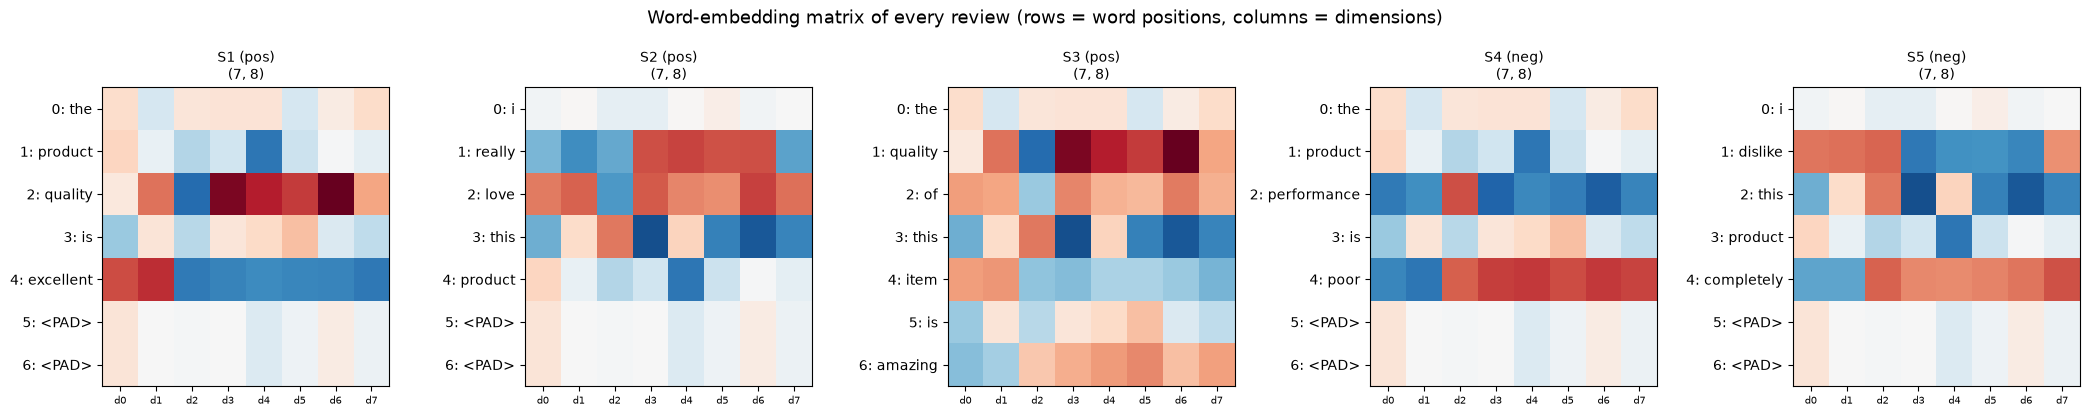

embedding tensor for all reviews: (5, 7, 8)

S1: 'The product quality is excellent'


,d0,d1,d2,d3,d4,d5,d6,d7
0: the,0.133,-0.128,0.093,0.103,0.103,-0.127,0.064,0.141
1: product,0.163,-0.056,-0.219,-0.152,-0.545,-0.163,-0.010,-0.071
2: quality,0.077,0.411,-0.583,0.709,0.593,0.530,0.755,0.297
3: is,-0.282,0.095,-0.211,0.092,0.147,0.230,-0.108,-0.192
4: excellent,0.494,0.556,-0.534,-0.504,-0.476,-0.496,-0.496,-0.542
5: <PAD>,0.099,-0.002,-0.014,-0.004,-0.100,-0.037,0.060,-0.045
6: <PAD>,0.099,-0.002,-0.014,-0.004,-0.100,-0.037,0.060,-0.045


In [11]:
E = W[X]    # trained embeddings, shape (5, 7, 8)

fig, axes = plt.subplots(1, 5, figsize=(21, 4.2))
for k, ax in enumerate(axes):
    ax.imshow(E[k], cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
    ax.set_yticks(range(MAX_LEN), [f"{p}: {id_to_word[t]}" for p, t in enumerate(X[k])])
    ax.set_xticks(range(EMB_DIM), [f"d{j}" for j in range(EMB_DIM)], fontsize=7)
    ax.set_title(f"{names[k]} ({'pos' if labels[k] else 'neg'})\n{E[k].shape}", fontsize=10)
fig.suptitle("Word-embedding matrix of every review (rows = word positions, columns = dimensions)", fontsize=13)
plt.tight_layout()
plt.show()

print("embedding tensor for all reviews:", E.shape)
print(f"\n{names[0]}: '{texts[0]}'")
pd.DataFrame(E[0], index=[f"{p}: {id_to_word[t]}" for p, t in enumerate(X[0])],
             columns=[f"d{j}" for j in range(EMB_DIM)]).round(3)

'product' found at (sentence, position): [('S1', 1), ('S2', 4), ('S4', 1), ('S5', 3)]


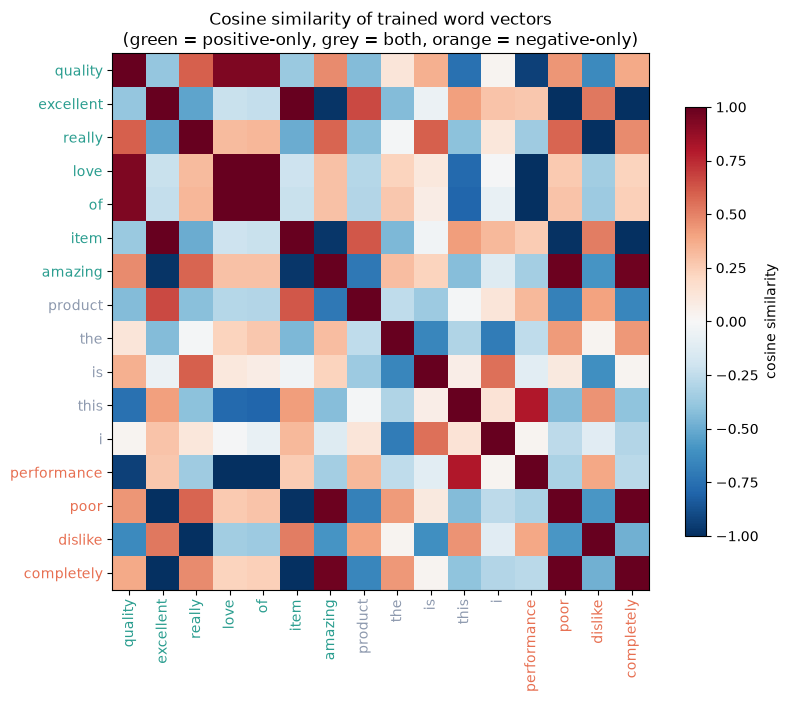

mean cosine, same sentiment group : -0.008 before -> +0.069 after training
mean cosine, opposite groups      : -0.011 before -> -0.147 after training
nearest to excellent : [('item', 1.0), ('product', 0.66), ('dislike', 0.53)]
nearest to amazing   : [('poor', 0.98), ('completely', 0.97), ('really', 0.58)]
nearest to poor      : [('completely', 0.99), ('amazing', 0.98), ('really', 0.58)]
nearest to dislike   : [('excellent', 0.53), ('item', 0.51), ('this', 0.45)]
nearest to product   : [('excellent', 0.66), ('item', 0.62), ('dislike', 0.4)]

words that share a position:
  cos(excellent, item) = +0.995   (S1 vs S3, both pos 4, both positive)
  cos(excellent, poor) = -0.997   (S1 vs S4, both pos 4, opposite labels)
  cos(item, completely) = -0.994   (S3 vs S5, both pos 4, opposite labels)
  cos(love, performance) = -0.995   (S2 vs S4, both pos 2, opposite labels)

Task 6 verified: same word -> same vector, and sentiment groups separate after training


In [12]:
# Same word, same vector: 'product' sits at different positions in S1, S2, S4, S5.
pid = word_to_id["product"]
where = [(k, p) for k in range(5) for p in range(MAX_LEN) if X[k, p] == pid]
print("'product' found at (sentence, position):", [(names[k], p) for k, p in where])
assert all(np.array_equal(E[k, p], W[pid]) for k, p in where)

# Cosine similarity between the 16 real words.
Wn = W[2:] / np.linalg.norm(W[2:], axis=1, keepdims=True)
cos_words = Wn @ Wn.T
order = sorted(range(16), key=lambda i: ["positive only", "both", "negative only"].index(groups[vocab_words[i]]))
ow = [vocab_words[i] for i in order]

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(cos_words[np.ix_(order, order)], cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(16), ow, rotation=90); ax.set_yticks(range(16), ow)
for t in ax.get_xticklabels() + ax.get_yticklabels():
    t.set_color(group_colour[groups[t.get_text()]])
fig.colorbar(im, shrink=0.8, label="cosine similarity")
ax.set_title("Cosine similarity of trained word vectors\n(green = positive-only, grey = both, orange = negative-only)")
plt.tight_layout()
plt.show()


def group_cosines(Wm):
    """Mean cosine within the same sentiment group vs across the two groups."""
    V = Wm / np.linalg.norm(Wm, axis=1, keepdims=True)
    pos = [word_to_id[w] for w in vocab_words if groups[w] == "positive only"]
    neg = [word_to_id[w] for w in vocab_words if groups[w] == "negative only"]
    within = [V[a] @ V[b] for g in (pos, neg) for a in g for b in g if a < b]
    across = [V[a] @ V[b] for a in pos for b in neg]
    return float(np.mean(within)), float(np.mean(across))


def neighbours(Wm, word, k=3):
    V = Wm[2:] / np.linalg.norm(Wm[2:], axis=1, keepdims=True)
    s = V @ V[vocab_words.index(word)]
    return [(vocab_words[j], round(float(s[j]), 2)) for j in np.argsort(-s) if vocab_words[j] != word][:k]


w_in0, w_ac0 = group_cosines(W_before)
w_in, w_ac = group_cosines(W)
print(f"mean cosine, same sentiment group : {w_in0:+.3f} before -> {w_in:+.3f} after training")
print(f"mean cosine, opposite groups      : {w_ac0:+.3f} before -> {w_ac:+.3f} after training")
for w in ["excellent", "amazing", "poor", "dislike", "product"]:
    print(f"nearest to {w:<10}: {neighbours(W, w)}")

# Flatten gives every position its own slice of the dense weights, so a word that occurs once is
# pushed along +/- the slice of the position it sits at. Words at the same position should line up.
same_pos = [("excellent", "item", "S1 vs S3, both pos 4, both positive"),
            ("excellent", "poor", "S1 vs S4, both pos 4, opposite labels"),
            ("item", "completely", "S3 vs S5, both pos 4, opposite labels"),
            ("love", "performance", "S2 vs S4, both pos 2, opposite labels")]
V = W / np.linalg.norm(W, axis=1, keepdims=True)
print("\nwords that share a position:")
for a, b, why in same_pos:
    print(f"  cos({a}, {b}) = {V[word_to_id[a]] @ V[word_to_id[b]]:+.3f}   ({why})")

# Verify: training made same-group words more alike than opposite-group words,
# and same-position words line up (+) or point opposite ways (-) according to their label.
assert w_in > w_ac
assert V[word_to_id["excellent"]] @ V[word_to_id["item"]] > 0.9
assert V[word_to_id["excellent"]] @ V[word_to_id["poor"]] < -0.9
checks["Task 6  embedding display and analysis"] = f"(5, 7, 8) tensor shown; within {w_in:+.2f} vs across {w_ac:+.2f}"
print("\nTask 6 verified: same word -> same vector, and sentiment groups separate after training")

Observation

- "product" sits at positions 1, 4, 1 and 3 in S1, S2, S4 and S5, and its vector is identical every time, so a basic embedding ignores context.
- After training, same-sentiment words have mean cosine +0.069 and opposite-sentiment words -0.147, up from about 0 for both on the random matrix.
- That gap is real but small, and the reason is position: the four word pairs that share a position have cosines of +0.995 or about -0.995.
- "excellent" and "item" both sit at position 4 of a positive review and end up almost the same vector (+0.995), while "excellent" and "poor" at position 4 point in opposite directions (-0.997).
- With Flatten, each position has its own slice of output weights, so a word learns "positive or negative *at this position*", not sentiment on its own.

## Task 7: Flatten each sentence into one vector

- Flattening reads the 7 x 8 matrix row by row into one 56-number vector, so positions 0-7 are the first word, 8-15 the second, and so on.
- The flattened vector is exactly what the sigmoid unit in Task 5 reads, so it is the latent representation the model used.
- I take it two ways: `reshape` by hand, and the output of the trained model's own `Flatten` layer, and they must match.

In [13]:
flat_manual = E.reshape(len(texts), MAX_LEN * EMB_DIM)
flatten_model = tf.keras.Model(model.input, model.get_layer("flatten").output)
flat = flatten_model.predict(X, verbose=0)

print("embedding tensor:", E.shape, "-> flattened:", flat.shape)
np.set_printoptions(precision=3, suppress=True, linewidth=110)
for k in range(len(texts)):
    print(f"\n{names[k]} '{texts[k]}'  ({flat.shape[1]} values)")
    print(flat[k])

# Verify 1: hand reshape == Keras Flatten layer.
assert flat.shape == (5, MAX_LEN * EMB_DIM) == (5, 56)
assert np.allclose(flat, flat_manual, atol=1e-7)
# Verify 2: slice p of the flat vector is the embedding of the word at position p.
assert all(np.allclose(flat[k, p * EMB_DIM:(p + 1) * EMB_DIM], W[X[k, p]]) for k in range(5) for p in range(MAX_LEN))
# Verify 3: the sigmoid unit applied to the flat vector reproduces the model's prediction.
w_d, b_d = model.get_layer("sentiment").get_weights()
assert np.allclose(1 / (1 + np.exp(-(flat @ w_d + b_d))), model.predict(X, verbose=0), atol=1e-5)
checks["Task 7  flattened vector per review"] = "5 x 56, reshape == Keras Flatten == what the classifier reads"
print("\nTask 7 verified: each review is one 56-D vector, identical by hand and by Keras")

embedding tensor: (5, 7, 8) -> flattened: (5, 56)

S1 'The product quality is excellent'  (56 values)
[ 0.133 -0.128  0.093  0.103  0.103 -0.127  0.064  0.141  0.163 -0.056 -0.219 -0.152 -0.545 -0.163 -0.01
 -0.071  0.077  0.411 -0.583  0.709  0.593  0.53   0.755  0.297 -0.282  0.095 -0.211  0.092  0.147  0.23
 -0.108 -0.192  0.494  0.556 -0.534 -0.504 -0.476 -0.496 -0.496 -0.542  0.099 -0.002 -0.014 -0.004 -0.1
 -0.037  0.06  -0.045  0.099 -0.002 -0.014 -0.004 -0.1   -0.037  0.06  -0.045]

S2 'I really love this product'  (56 values)
[-0.025  0.008 -0.068 -0.067  0.006  0.052 -0.024 -0.004 -0.347 -0.47  -0.388  0.486  0.509  0.479  0.484
 -0.407  0.393  0.445 -0.435  0.461  0.367  0.348  0.518  0.417 -0.366  0.139  0.395 -0.662  0.168 -0.508
 -0.643 -0.5    0.163 -0.056 -0.219 -0.152 -0.545 -0.163 -0.01  -0.071  0.099 -0.002 -0.014 -0.004 -0.1
 -0.037  0.06  -0.045  0.099 -0.002 -0.014 -0.004 -0.1   -0.037  0.06  -0.045]

S3 'The quality of this item is amazing'  (56 values)
[ 0.133 -

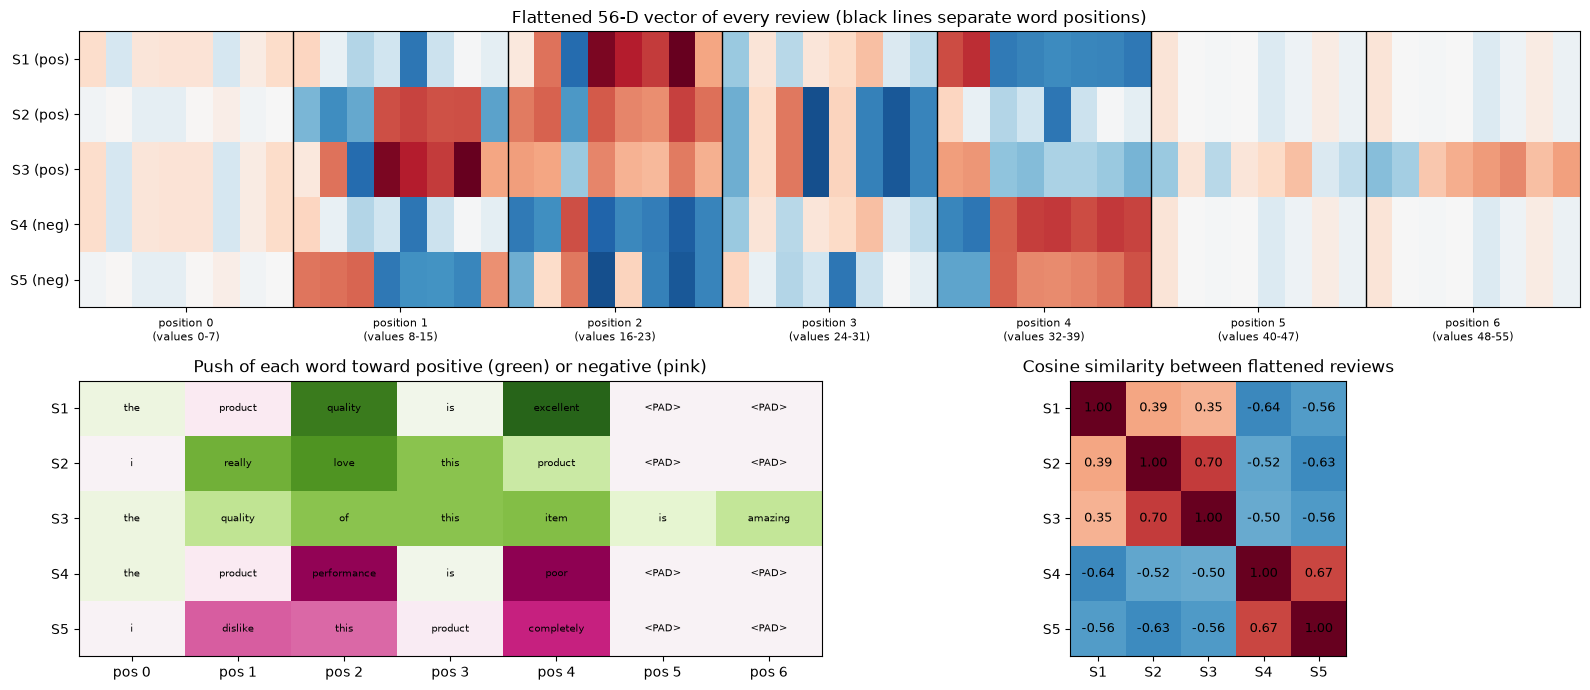

sentence cosine similarity:
        S1     S2     S3     S4     S5
S1  1.000  0.391  0.351 -0.644 -0.559
S2  0.391  1.000  0.698 -0.520 -0.628
S3  0.351  0.698  1.000 -0.503 -0.564
S4 -0.644 -0.520 -0.503  1.000  0.668
S5 -0.559 -0.628 -0.564  0.668  1.000

saved outputs/flattened_vectors.csv


In [14]:
fig = plt.figure(figsize=(16, 7))
ax = fig.add_subplot(2, 1, 1)
flim = np.abs(flat).max()
ax.imshow(flat, cmap="RdBu_r", vmin=-flim, vmax=flim, aspect="auto")
for p in range(1, MAX_LEN):
    ax.axvline(p * EMB_DIM - 0.5, color="black", lw=1)
ax.set_yticks(range(5), [f"{n} ({'pos' if l else 'neg'})" for n, l in zip(names, labels)])
ax.set_xticks([p * EMB_DIM + 3.5 for p in range(MAX_LEN)], [f"position {p}\n(values {p * 8}-{p * 8 + 7})" for p in range(MAX_LEN)], fontsize=8)
ax.set_title("Flattened 56-D vector of every review (black lines separate word positions)")

# Contribution of each position to the sentiment score: slice of flat vector . slice of dense weights.
contrib = (flat * w_d.ravel()).reshape(5, MAX_LEN, EMB_DIM).sum(axis=2)
ax2 = fig.add_subplot(2, 2, 3)
clim = np.abs(contrib).max()
ax2.imshow(contrib, cmap="PiYG", vmin=-clim, vmax=clim, aspect="auto")
for r in range(5):
    for c in range(MAX_LEN):
        ax2.text(c, r, id_to_word[X[r, c]], ha="center", va="center", fontsize=7)
ax2.set_yticks(range(5), names); ax2.set_xticks(range(MAX_LEN), [f"pos {p}" for p in range(MAX_LEN)])
ax2.set_title("Push of each word toward positive (green) or negative (pink)")

ax3 = fig.add_subplot(2, 2, 4)
fn = flat / np.linalg.norm(flat, axis=1, keepdims=True)
cos_sent = fn @ fn.T
ax3.imshow(cos_sent, cmap="RdBu_r", vmin=-1, vmax=1)
for r in range(5):
    for c in range(5):
        ax3.text(c, r, f"{cos_sent[r, c]:.2f}", ha="center", va="center", fontsize=9)
ax3.set_xticks(range(5), names); ax3.set_yticks(range(5), names)
ax3.set_title("Cosine similarity between flattened reviews")
plt.tight_layout()
plt.show()

pd.DataFrame(flat, index=names).to_csv("outputs/flattened_vectors.csv")
print("sentence cosine similarity:\n", pd.DataFrame(cos_sent, index=names, columns=names).round(3))
print("\nsaved outputs/flattened_vectors.csv")

Observation

- Every review is now a 56-D vector (7 positions x 8 dimensions), and the hand reshape equals the Keras `Flatten` output exactly.
- In S1 and S2 the last 16 values are the same `<PAD>` vector twice, and S3 is the only review whose last block holds real words.
- Positive reviews have cosine +0.35 to +0.70 with each other and -0.50 to -0.64 with the negative ones, so the flattened vectors separate the two classes cleanly.
- The contribution map shows "excellent", "quality", "poor" and "performance" doing most of the work, while "the" and `<PAD>` contribute almost nothing.

## Task 8: Visualise the embeddings in 2-D with PCA

- PCA finds the two directions along which the 8-D word vectors vary most and projects every word onto them.
- `<PAD>` and `<OOV>` are left out, because they are not words and `<OOV>` never trained.
- The untrained matrix goes through the same PCA, so any structure after training can be credited to training and not to chance.

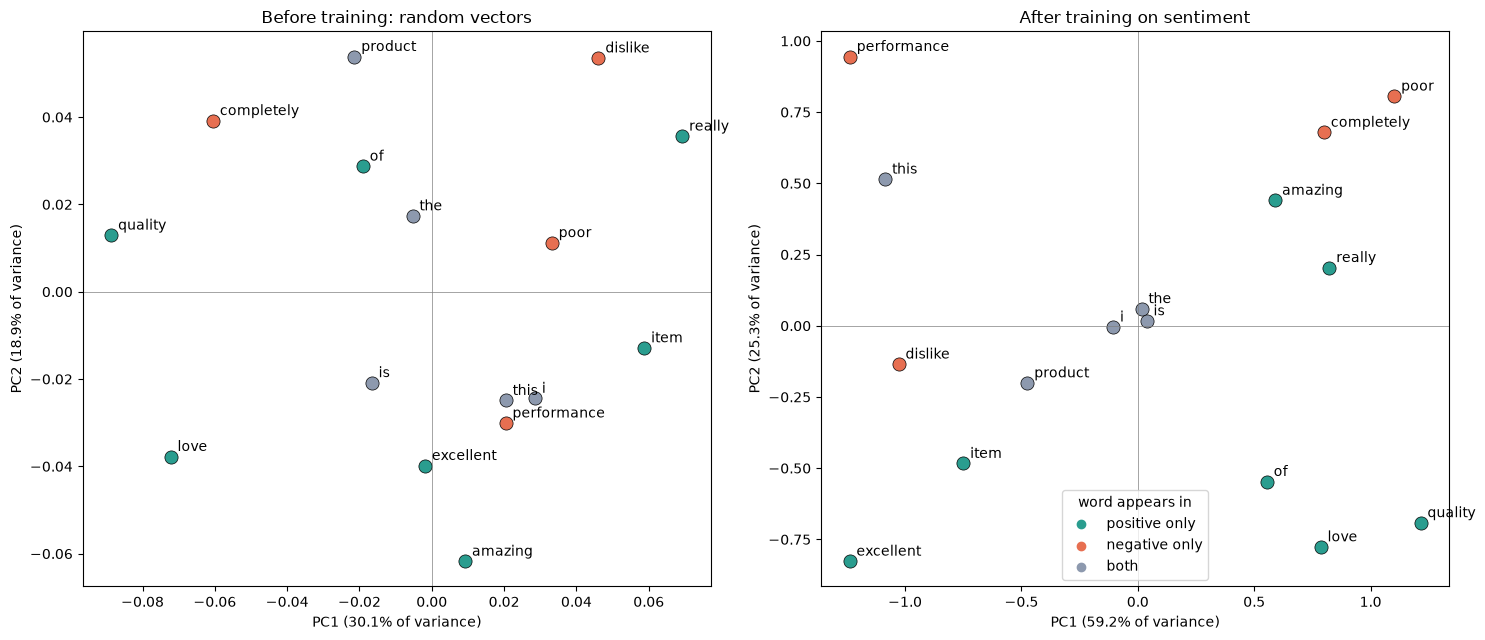

PC1 coordinate by group (after training):
  positive only  mean +0.282   words: quality, excellent, really, love, of, item, amazing
  negative only  mean -0.091   words: performance, poor, dislike, completely
  both           mean -0.323   words: product, the, is, this, i

variance kept in 2-D: 49.1% before, 84.5% after

Task 8 verified: 16 words projected from 8-D to 2-D


In [15]:
def pca_plot(ax, Wm, title):
    pca = PCA(n_components=2, random_state=SEED)
    Z = pca.fit_transform(Wm[2:])
    for (x, y), w in zip(Z, vocab_words):
        ax.scatter(x, y, s=90, color=group_colour[groups[w]], edgecolor="black", lw=0.5)
        ax.annotate(w, (x, y), xytext=(5, 4), textcoords="offset points", fontsize=10)
    r = pca.explained_variance_ratio_
    ax.set_xlabel(f"PC1 ({r[0]:.1%} of variance)")
    ax.set_ylabel(f"PC2 ({r[1]:.1%} of variance)")
    ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
    ax.set_title(title)
    return pca, Z


fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
pca0, Z0 = pca_plot(axes[0], W_before, "Before training: random vectors")
pca1, Z1 = pca_plot(axes[1], W, "After training on sentiment")
for g, c in group_colour.items():
    axes[1].scatter([], [], color=c, label=g)
axes[1].legend(title="word appears in", loc="best")
plt.tight_layout()
plt.show()

pc1 = pd.Series(Z1[:, 0], index=vocab_words)
print("PC1 coordinate by group (after training):")
for g in group_colour:
    ws = [w for w in vocab_words if groups[w] == g]
    print(f"  {g:<14} mean {pc1[ws].mean():+.3f}   words: {', '.join(ws)}")
print(f"\nvariance kept in 2-D: {pca0.explained_variance_ratio_.sum():.1%} before, {pca1.explained_variance_ratio_.sum():.1%} after")

# Verify: PCA shapes are right and 2 components never keep more than all of the variance.
assert Z1.shape == (16, 2) and pca1.explained_variance_ratio_.sum() <= 1.0
checks["Task 8  2-D PCA of word embeddings"] = f"16 words plotted, 2 PCs keep {pca1.explained_variance_ratio_.sum():.0%} of variance"
print("\nTask 8 verified: 16 words projected from 8-D to 2-D")

Observation

- Before training the 2 components keep only 49.1% of the variance and the words are scattered with no pattern, as random vectors should be.
- After training they keep 84.5%, so training packed the 8-D vectors into a nearly flat 2-D structure.
- The plot does not split cleanly into positive and negative: "excellent" sits near "dislike", and "poor" sits near "amazing".
- The four shared words "the", "is", "i" and "product" sit near the centre, which matches their small movement in Task 5.
- The word map groups words by position times label, as Task 6 found, and Part B shows that average pooling changes this.

### Step 8b: The five reviews in the same kind of 2-D view

- The same PCA idea applied to the 56-D flattened vectors shows where each whole review lands.

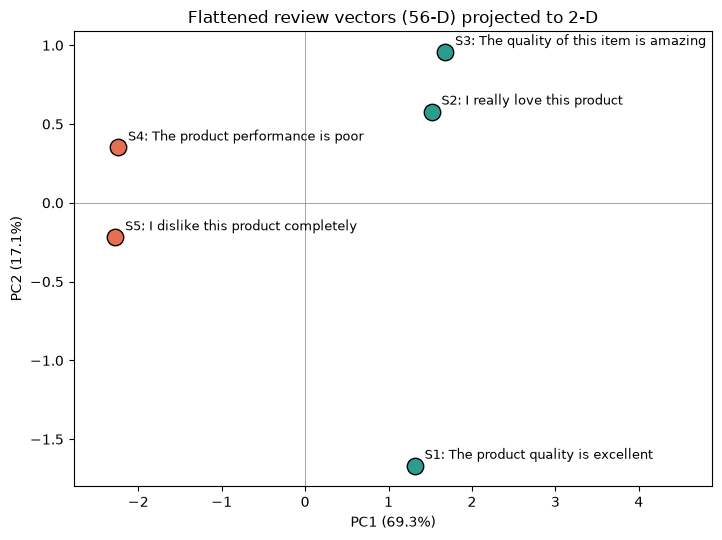

      PC1    PC2  label
S1  1.317 -1.669      1
S2  1.517  0.579      1
S3  1.680  0.957      1
S4 -2.239  0.351      0
S5 -2.275 -0.219      0


In [16]:
pca_s = PCA(n_components=2, random_state=SEED)
Zs = pca_s.fit_transform(flat)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for (x, y), n, t, l in zip(Zs, names, texts, labels):
    ax.scatter(x, y, s=140, color=C_POS if l else C_NEG, edgecolor="black")
    ax.annotate(f"{n}: {t}", (x, y), xytext=(7, 5), textcoords="offset points", fontsize=9)
ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
r = pca_s.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({r[0]:.1%})"); ax.set_ylabel(f"PC2 ({r[1]:.1%})")
ax.set_xlim(Zs[:, 0].min() - 0.5, Zs[:, 0].max() + 3.2)
ax.set_title("Flattened review vectors (56-D) projected to 2-D")
plt.tight_layout()
plt.show()
print(pd.DataFrame(Zs, index=names, columns=["PC1", "PC2"]).assign(label=labels.astype(int)).round(3))

Observation

- PC1 alone (69.3% of the variance) puts all three positive reviews on the right (+1.32 to +1.68) and both negative reviews on the left (-2.24, -2.28).
- So sentiment shows up clearly at the review level after flattening, even though single words do not group by sentiment in Task 8.